# **Capstone Project: *JobCompass***
# ***Data Science***
---
- **Anggota 1:** Muchlis Ar Wicaksana - CDCC009D6Y2743
- **Anggota 2:** Lintang Zidan Dzaki - CDCC009D6Y2739

# **Project Setup & Definisi Masalah**

## **Permasalahan:**
---
Pencari kerja sering kesulitan mengetahui secara pasti korelasi antara CV mereka dengan spesifikasi lowongan yang tersedia. Pencarian manual memakan waktu lama, sedangkan perusahaan juga kesulitan memfilter kandidat yang benar-benar relevan.

## **Solusi Utama**
---
Membangun **JobCompass**, sebuah sistem berbasis NLP yang mampu mencocokkan CV pengguna dengan deskripsi lowongan secara otomatis, sekaligus menyajikan dashboard analitik terkait tren pasar kerja saat ini.

## **Pertanyaan Bisnis:**
---
1. Apa saja peran (Job Title) yang paling banyak dibutuhkan di pasar saat ini?
2. Keterampilan (Key Skills) apa saja yang paling krusial dan sering dicari oleh perusahaan?
3. Bagaimana perbandingan rata-rata kompensasi finansial (Gaji) pada berbagai kategori pekerjaan?

In [1]:
# Import Library

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# **Data Wrangling**

## **Gathering Data**

In [2]:
path = kagglehub.dataset_download("shivamshrivastava21/indian-job-market-dataset-2025-2026")
df = pd.read_excel(os.path.join(path, "indian-job-market-dataset-2025.xlsx"))

df.head()

100%|██████████| 30.2M/30.2M [00:00<00:00, 142MB/s]

Extracting files...


,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
0,Sr. HR Recruiter (NON IT),270925008041,INR,6 Days Ago,Orion,"Communication,Manpower,Staffing,Convincing Pow...",2-4 Yrs,2-4 Lacs PA,Kolkata(Chinar Park),645563,NaN,NaN,Preferred candidate profile . .,200000.0,400000.0,2.0,4.0
1,Fire And Safety Officer,270925007584,INR,6 Days Ago,"Apollo Hospitals International Limited, Ahmedabad","Safety Officer Activities,Fire Protection,Fire...",6-11 Yrs,3-5 Lacs PA,"Gandhinagar, Ahmedabad",14072,5162.0,4.0,"Ensure active Fire Protection System,such as F...",300000.0,500000.0,6.0,11.0
2,Opening For Performance Marketing - Chennai,270925007492,INR,6 Days Ago,TVS Credit Services Ltd,"Performance Marketing,User Acquisition,growth ...",12-18 Yrs,Not disclosed,Chennai,1324750,2892.0,4.2,MBA Marketing (preferred Tier II or III B- Sch...,0.0,0.0,12.0,18.0
3,Medical Billing Executive,270925007443,INR,6 Days Ago,GNR Global Services,"Fluent English,Spoken English,Good English Com...",0-3 Yrs,"70,000-2 Lacs PA","Mohali, Chandigarh, Kharar, Zirakpur",123804403,NaN,NaN,Job Title-Medical Billing Executive\nLocation-...,70000.0,200000.0,0.0,3.0
4,Senior Group Product Manager - CNS Therapy,270925007430,INR,6 Days Ago,Cadila Pharmaceuticals,"Product Marketing,CNS,Product Management,Nephr...",5-10 Yrs,8-18 Lacs PA,Ahmedabad,14957,2134.0,3.4,Principal Tasks & Responsibilities : (Please w...,800000.0,1800000.0,5.0,10.0


## **Assessing Data**

In [3]:
# Informasi Umum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97929 entries, 0 to 97928
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              97929 non-null  object 
 1   jobId              97929 non-null  int64  
 2   currency           97929 non-null  object 
 3   jobUploaded        97929 non-null  object 
 4   companyName        97925 non-null  object 
 5   tagsAndSkills      97358 non-null  object 
 6   experience         95824 non-null  object 
 7   salary             97929 non-null  object 
 8   location           97929 non-null  object 
 9   companyId          97929 non-null  int64  
 10  ReviewsCount       62677 non-null  float64
 11  AggregateRating    62677 non-null  float64
 12  jobDescription     97929 non-null  object 
 13  minimumSalary      97358 non-null  float64
 14  maximumSalary      97358 non-null  float64
 15  minimumExperience  97358 non-null  float64
 16  maximumExperience  973

In [4]:
# Mengecek Missing Values dan Duplikat Data
missing_values = df.isnull().sum()
duplicated_data = df.duplicated().sum()

print('Missing Values:')
print(missing_values)
print('\nDuplicated Data:')
print(duplicated_data)

Missing Values:
title                    0
jobId                    0
currency                 0
jobUploaded              0
companyName              4
tagsAndSkills          571
experience            2105
salary                   0
location                 0
companyId                0
ReviewsCount         35252
AggregateRating      35252
jobDescription           0
minimumSalary          571
maximumSalary          571
minimumExperience      571
maximumExperience      571
dtype: int64

Duplicated Data:
247


## **Cleaning Data**

In [5]:
# Membuat kolom yang diperlukan
df = pd.DataFrame(df[['jobId','title','tagsAndSkills', 'jobDescription', 'minimumSalary', 'maximumSalary']])
df = df.rename(columns={
    'jobId': 'job_id',
    'title': 'job_title',
    'tagsAndSkills': 'job_skill',
    'jobDescription': 'job_description',
    'minimumSalary': 'min_salary',
    'maximumSalary': 'max_salary',
})
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97929 entries, 0 to 97928
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_id           97929 non-null  int64  
 1   job_title        97929 non-null  object 
 2   job_skill        97358 non-null  object 
 3   job_description  97929 non-null  object 
 4   min_salary       97358 non-null  float64
 5   max_salary       97358 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 4.5+ MB


,job_id,job_title,job_skill,job_description,min_salary,max_salary
0,270925008041,Sr. HR Recruiter (NON IT),"Communication,Manpower,Staffing,Convincing Pow...",Preferred candidate profile . .,200000.0,400000.0
1,270925007584,Fire And Safety Officer,"Safety Officer Activities,Fire Protection,Fire...","Ensure active Fire Protection System,such as F...",300000.0,500000.0
2,270925007492,Opening For Performance Marketing - Chennai,"Performance Marketing,User Acquisition,growth ...",MBA Marketing (preferred Tier II or III B- Sch...,0.0,0.0
3,270925007443,Medical Billing Executive,"Fluent English,Spoken English,Good English Com...",Job Title-Medical Billing Executive\nLocation-...,70000.0,200000.0
4,270925007430,Senior Group Product Manager - CNS Therapy,"Product Marketing,CNS,Product Management,Nephr...",Principal Tasks & Responsibilities : (Please w...,800000.0,1800000.0


In [6]:
# Menangani Missing Value
df.dropna(inplace=True)

# Menangani data duplikat
df.drop_duplicates(inplace=True)

# Hapus semua tag HTML (termasuk <br>, <b>, dll) dan ubah menjadi spasi
df['job_description'] = df['job_description'].str.replace(r'<[^>]+>', ' ', regex=True)

# Hapus tanda baca berlebih atau karakter aneh jika ada (opsional)
df['job_description'] = df['job_description'].str.replace(r'[^\w\s\-\.\/]', '', regex=True)

# Rapikan spasi ganda yang muncul akibat penghapusan tag HTML
df['job_description'] = df['job_description'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Casefolding menjadi huruf kecil
df['job_title'] = df['job_title'].str.lower()
df['job_skill'] = df['job_skill'].str.lower()
df['job_description'] = df['job_description'].str.lower()

df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 97110 entries, 0 to 97928
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_id           97110 non-null  int64  
 1   job_title        97110 non-null  object 
 2   job_skill        97110 non-null  object 
 3   job_description  97110 non-null  object 
 4   min_salary       97110 non-null  float64
 5   max_salary       97110 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 5.2+ MB


,job_id,job_title,job_skill,job_description,min_salary,max_salary
0,270925008041,sr. hr recruiter (non it),"communication,manpower,staffing,convincing pow...",preferred candidate profile . .,200000.0,400000.0
1,270925007584,fire and safety officer,"safety officer activities,fire protection,fire...",ensure active fire protection systemsuch as fi...,300000.0,500000.0
2,270925007492,opening for performance marketing - chennai,"performance marketing,user acquisition,growth ...",mba marketing preferred tier ii or iii b- scho...,0.0,0.0
3,270925007443,medical billing executive,"fluent english,spoken english,good english com...",job title-medical billing executive location-m...,70000.0,200000.0
4,270925007430,senior group product manager - cns therapy,"product marketing,cns,product management,nephr...",principal tasks responsibilities please write ...,800000.0,1800000.0
5,270925007323,senior accountant,"tds filing,itr,gst filing,balance sheet finali...",preferred candidate profile experience 10-15 y...,350000.0,600000.0
6,270925007180,maintenance technician,"booth,conveyor,special process,utility mainten...",job description knowledge of powder coating eq...,0.0,0.0
7,270925006659,officer/engineer technical,"m.s office,sap,computer skills,ms office,techn...",ready to work in all shifts . understanding of...,0.0,0.0
8,270925006525,officer- technical lab,"sap,laboratory knowledge,microsoft,technical,lab",preferred candidate profile . tyre industry ex...,0.0,0.0
9,270925006315,site reliability engineer,"sre,azure devops,monitoring tools,site,site re...",develop automation scripts using python or oth...,0.0,0.0


In [7]:
# Tokenized kolom job_skill
df['job_skill_set'] = df['job_skill'].apply(lambda x: x.split(','))
df.drop(['job_skill'], axis=1, inplace=True)

df.head()

,job_id,job_title,job_description,min_salary,max_salary,job_skill_set
0,270925008041,sr. hr recruiter (non it),preferred candidate profile . .,200000.0,400000.0,"[communication, manpower, staffing, convincing..."
1,270925007584,fire and safety officer,ensure active fire protection systemsuch as fi...,300000.0,500000.0,"[safety officer activities, fire protection, f..."
2,270925007492,opening for performance marketing - chennai,mba marketing preferred tier ii or iii b- scho...,0.0,0.0,"[performance marketing, user acquisition, grow..."
3,270925007443,medical billing executive,job title-medical billing executive location-m...,70000.0,200000.0,"[fluent english, spoken english, good english ..."
4,270925007430,senior group product manager - cns therapy,principal tasks responsibilities please write ...,800000.0,1800000.0,"[product marketing, cns, product management, n..."


# **Feature Engineering**
---
**Data Dictionary (Fitur Tambahan):**
- `category`: kolom untuk mengelompokkan berbagai variasi nama jabatan (job_title) yang spesifik ke dalam bidang, industri, atau tingkat keahlian yang lebih luas dan terstandarisasi.
- `avg_salary`: kolom untuk menghitung rata-rata dari minimum dan maksimum gaji setiap role
- `avg_sal_dollar`: Konversi kolom mata uang dari rupee ke dollar

In [8]:
# Membuat kategori label berdasarkan job_title
def assign_category(title):
    t = title.lower()

    # HR dulu sebelum kata umum lainnya
    if any(k in t for k in ['human resource', 'recruiter', 'recruiting', 'recruitment',
                              'staffing', 'payroll', 'manpower', 'talent acquisition',
                              ' hr ', 'hr executive', 'hr manager', 'hr officer',
                              'hrbp', 'people operations']):
        return 'Human Resources'

    # Customer Service SEBELUM IT — cegah konflik 'support', 'voice'
    elif any(k in t for k in ['customer service', 'customer care', 'customer support',
                                'customer success', 'call center', 'call centre',
                                'bpo', 'telecaller', 'telemarketing',
                                'voice process', 'chat process', 'non-voice',
                                'blended process', 'international voice',
                                'service desk', 'help desk', 'helpdesk',
                                'client servicing', 'customer relation']):
        return 'Customer Service'

    elif any(k in t for k in ['sales', 'business development', 'bd manager',
                                'relationship manager', 'account manager',
                                'marketing', 'digital marketing', 'performance marketing',
                                'brand manager', 'seo', 'sem', 'social media',
                                'content marketing', 'pre-sales', 'inside sales',
                                'field sales', 'channel sales']):
        return 'Sales & Business Development'

    elif any(k in t for k in ['finance', 'financial', 'accounting', 'accountant',
                                'audit', 'auditor', 'accounts payable', 'accounts receivable',
                                'banking', 'insurance', 'tax', 'taxation', 'treasury',
                                'credit', 'investment', 'equity', 'wealth management',
                                'compliance', 'risk management', 'actuarial',
                                'chartered accountant', 'bookkeeping']):
        return 'Finance & Accounting'

    elif any(k in t for k in ['software', 'developer', 'engineer', 'devops',
                                'cloud', 'aws', 'azure', 'gcp', 'kubernetes',
                                'data scientist', 'data analyst', 'data engineer',
                                'machine learning', 'deep learning', 'artificial intelligence',
                                'java', 'python', 'javascript', 'react', 'angular',
                                'android', 'ios', 'flutter', 'fullstack', 'full stack',
                                'backend', 'frontend', 'sap', 'oracle', 'erp',
                                'salesforce', 'servicenow', 'network', 'cybersecurity',
                                'information security', 'database', 'sql', 'etl',
                                'qa engineer', 'test engineer', 'sdet', 'automation tester',
                                'product manager', 'product owner', 'it ',
                                'information technology', 'tech lead', 'system admin',
                                'infrastructure', 'embedded', 'firmware', 'hardware engineer',
                                'windchill', 'catia', 'solidworks', 'autocad']):
        return 'Information Technology'

    elif any(k in t for k in ['operations', 'supply chain', 'logistics', 'procurement',
                                'warehouse', 'inventory', 'purchase manager',
                                'production', 'manufacturing', 'quality control',
                                'quality assurance', 'plant manager', 'maintenance',
                                'facility', 'safety officer', 'store manager',
                                'retail', 'branch manager', 'fleet', 'dispatch']):
        return 'Operations'

    elif any(k in t for k in ['medical', 'doctor', 'physician', 'nurse', 'nursing',
                                'clinical', 'pharma', 'pharmaceutical', 'hospital',
                                'radiologist', 'pathologist', 'dentist', 'therapist',
                                'optometrist', 'surgeon', 'medical coder',
                                'medical billing', 'healthcare']):
        return 'Healthcare'

    elif any(k in t for k in ['teacher', 'professor', 'lecturer', 'faculty',
                                'trainer', 'training', 'educator', 'academic',
                                'counsellor', 'tutor', 'teaching']):
        return 'Education'

    elif any(k in t for k in ['graphic designer', 'ui designer', 'ux designer',
                                'ui/ux', 'visual designer', 'motion designer',
                                'video editor', 'content writer', 'copywriter',
                                'creative director', 'art director', 'animator']):
        return 'Design & Creative'

    return None

In [9]:
df['category'] = df['job_title'].apply(assign_category)   # buat kolom category dulu
df = df[df['category'].notna()].reset_index(drop=True)    # filter category yang hasilnya None

LABEL_NAMES = [
    'Human Resources',
    'Customer Service',
    'Sales & Business Development',
    'Finance & Accounting',
    'Information Technology',
    'Operations',
    'Healthcare',
    'Education',
    'Design & Creative'
]
LABEL_MAP = {name: idx for idx, name in enumerate(LABEL_NAMES)}
df['category'].map(LABEL_MAP)

print("Category distribution:")
print(df['category'].value_counts())
print("\nTotal samples:", len(df))
df.head()

Category distribution:
category
Information Technology          30499
Sales & Business Development    13787
Finance & Accounting             4840
Customer Service                 4445
Operations                       4026
Human Resources                  2770
Healthcare                       1794
Education                        1552
Design & Creative                 955
Name: count, dtype: int64

Total samples: 64668


,job_id,job_title,job_description,min_salary,max_salary,job_skill_set,category
0,270925008041,sr. hr recruiter (non it),preferred candidate profile . .,200000.0,400000.0,"[communication, manpower, staffing, convincing...",Human Resources
1,270925007584,fire and safety officer,ensure active fire protection systemsuch as fi...,300000.0,500000.0,"[safety officer activities, fire protection, f...",Operations
2,270925007492,opening for performance marketing - chennai,mba marketing preferred tier ii or iii b- scho...,0.0,0.0,"[performance marketing, user acquisition, grow...",Sales & Business Development
3,270925007443,medical billing executive,job title-medical billing executive location-m...,70000.0,200000.0,"[fluent english, spoken english, good english ...",Healthcare
4,270925007430,senior group product manager - cns therapy,principal tasks responsibilities please write ...,800000.0,1800000.0,"[product marketing, cns, product management, n...",Information Technology


In [10]:
df['avg_salary'] = df[['min_salary', 'max_salary']].mean(axis=1)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64668 entries, 0 to 64667
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_id           64668 non-null  int64  
 1   job_title        64668 non-null  object 
 2   job_description  64668 non-null  object 
 3   min_salary       64668 non-null  float64
 4   max_salary       64668 non-null  float64
 5   job_skill_set    64668 non-null  object 
 6   category         64668 non-null  object 
 7   avg_salary       64668 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 3.9+ MB


,job_id,job_title,job_description,min_salary,max_salary,job_skill_set,category,avg_salary
0,270925008041,sr. hr recruiter (non it),preferred candidate profile . .,200000.0,400000.0,"[communication, manpower, staffing, convincing...",Human Resources,300000.0
1,270925007584,fire and safety officer,ensure active fire protection systemsuch as fi...,300000.0,500000.0,"[safety officer activities, fire protection, f...",Operations,400000.0
2,270925007492,opening for performance marketing - chennai,mba marketing preferred tier ii or iii b- scho...,0.0,0.0,"[performance marketing, user acquisition, grow...",Sales & Business Development,0.0
3,270925007443,medical billing executive,job title-medical billing executive location-m...,70000.0,200000.0,"[fluent english, spoken english, good english ...",Healthcare,135000.0
4,270925007430,senior group product manager - cns therapy,principal tasks responsibilities please write ...,800000.0,1800000.0,"[product marketing, cns, product management, n...",Information Technology,1300000.0


In [11]:
df['avg_sal_dollar'] = df['avg_salary'] * 0.010
df.head()

,job_id,job_title,job_description,min_salary,max_salary,job_skill_set,category,avg_salary,avg_sal_dollar
0,270925008041,sr. hr recruiter (non it),preferred candidate profile . .,200000.0,400000.0,"[communication, manpower, staffing, convincing...",Human Resources,300000.0,3000.0
1,270925007584,fire and safety officer,ensure active fire protection systemsuch as fi...,300000.0,500000.0,"[safety officer activities, fire protection, f...",Operations,400000.0,4000.0
2,270925007492,opening for performance marketing - chennai,mba marketing preferred tier ii or iii b- scho...,0.0,0.0,"[performance marketing, user acquisition, grow...",Sales & Business Development,0.0,0.0
3,270925007443,medical billing executive,job title-medical billing executive location-m...,70000.0,200000.0,"[fluent english, spoken english, good english ...",Healthcare,135000.0,1350.0
4,270925007430,senior group product manager - cns therapy,principal tasks responsibilities please write ...,800000.0,1800000.0,"[product marketing, cns, product management, n...",Information Technology,1300000.0,13000.0


In [12]:
df.to_csv('dataset_clean.csv', index=False)
print("Data berhasil diekspor sebagai 'dataset_clean.csv'")

Data berhasil diekspor sebagai 'dataset_clean.csv'


# **EDA & ExDA**

## **Pertanyaan 1**
---
Apa saja peran (Roles Category) yang paling banyak dibutuhkan di pasar saat ini?

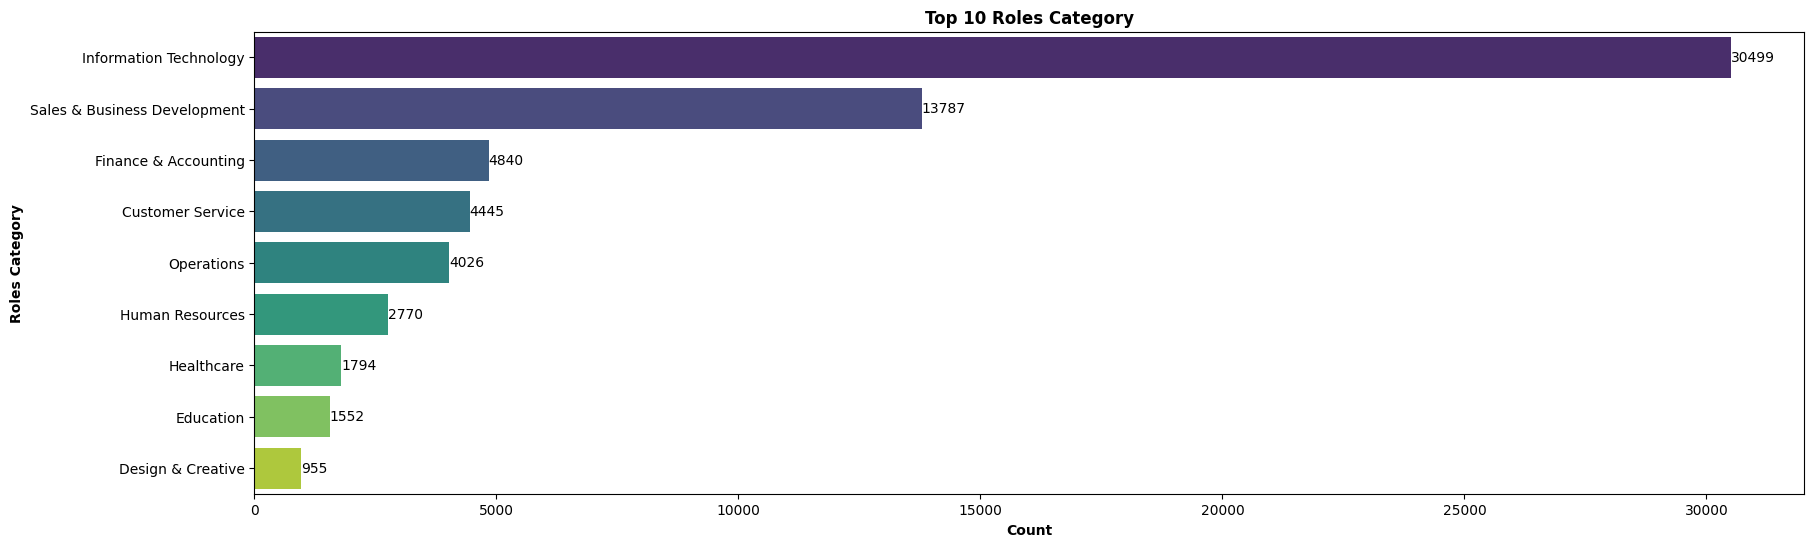

In [13]:
plt.figure(figsize=(20, 6))
top_roles = df['category'].value_counts().head(10)
ax = sns.barplot(x=top_roles.values, y=top_roles.index, hue=top_roles.index, palette='viridis', legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Top 10 Roles Category', fontweight='bold')
plt.xlabel('Count', fontweight='bold')
plt.ylabel('Roles Category', fontweight='bold')
plt.show()

- **Dominasi Pasar:** Berdasarkan volume lowongan saat ini, kategori Information Technology merupakan sektor yang paling agresif melakukan perekrutan tenaga kerja baru.
- **Peta Penyerapan Tenaga Kerja:** Perbedaan tinggi batang grafik menunjukkan ketimpangan penyerapan kebutuhan industri. Sektor dengan volume rekrutmen tinggi mencerminkan area ekspansi bisnis utama korporasi saat ini.
- **Kesimpulan:** Perusahaan sedang berfokus melakukan investasi besar-besaran pada sektor-sektor teratas. Bagi institusi pendidikan atau pencari kerja, menyelaraskan keahlian ke arah kategori dominan ini akan memperbesar peluang keterserapan di bursa kerja.

## **Pertanyaan 2**
---
Keterampilan (Key Skills) apa saja yang paling krusial dan sering dicari oleh perusahaan?

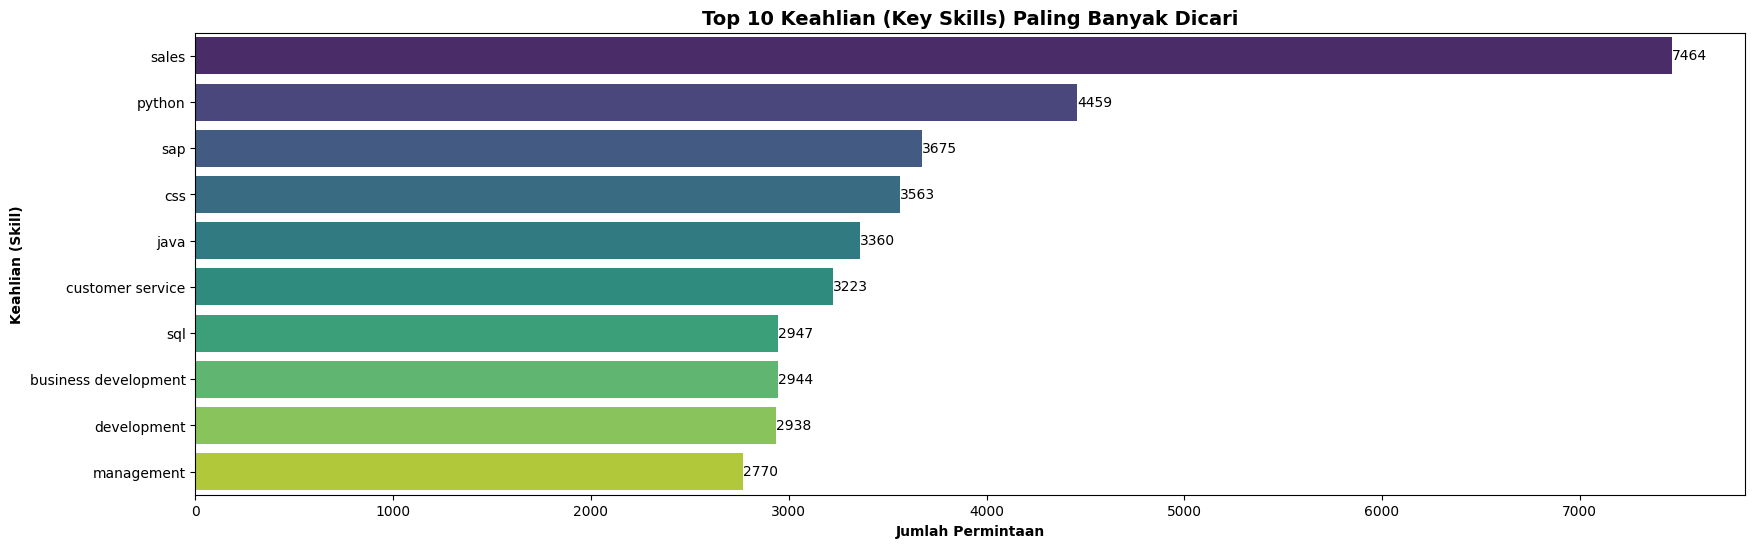

In [14]:
# Memecah list skill menjadi baris individual
skill = df.explode('job_skill_set')
# Menghilangkan string kosong
exploded_skills = skill[skill['job_skill_set'] != '']

plt.figure(figsize=(20, 6))
top_skills = exploded_skills['job_skill_set'].value_counts().head(10)
ax = sns.barplot(x=top_skills.values, y=top_skills.index, hue=top_skills.index, palette='viridis', legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Top 10 Keahlian (Key Skills) Paling Banyak Dicari', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Permintaan', fontweight='bold')
plt.ylabel('Keahlian (Skill)', fontweight='bold')
plt.show()

- **Keterampilan Paling Utama:** Berdasarkan ekstraksi data tekstual lowongan, keterampilan Sales menempati posisi teratas sebagai core skill yang paling sering disyaratkan oleh korporasi.
- **Pola Kebutuhan Korporasi:** Keterampilan dasar manajemen/komunikasi berdampingan erat dengan kapabilitas teknis (seperti pengolahan data atau teknologi informasi). Ini membuktikan bahwa industri saat ini mencari karakter kandidat yang bersifat T-Shaped (memiliki keahlian spesifik yang dalam namun ditunjang koordinasi umum yang luas).
- **Kesimpulan Jawaban Bisnis:** Keterampilan yang paling krusial bukan lagi sekadar kemampuan teknis tunggal, melainkan kombinasi fleksibel antara alat produktivitas kerja (data-driven tools) dan kecakapan manajerial eksekusi proyek. Fokus pengembangan diri pada top 3 keahlian di atas akan memberikan keunggulan kompetitif terbesar bagi kandidat di pasar kerja global.

## **Pertanyaan 3**
---
Bagaimana perbandingan rata-rata kompensasi finansial (Gaji) pada berbagai kategori pekerjaan??

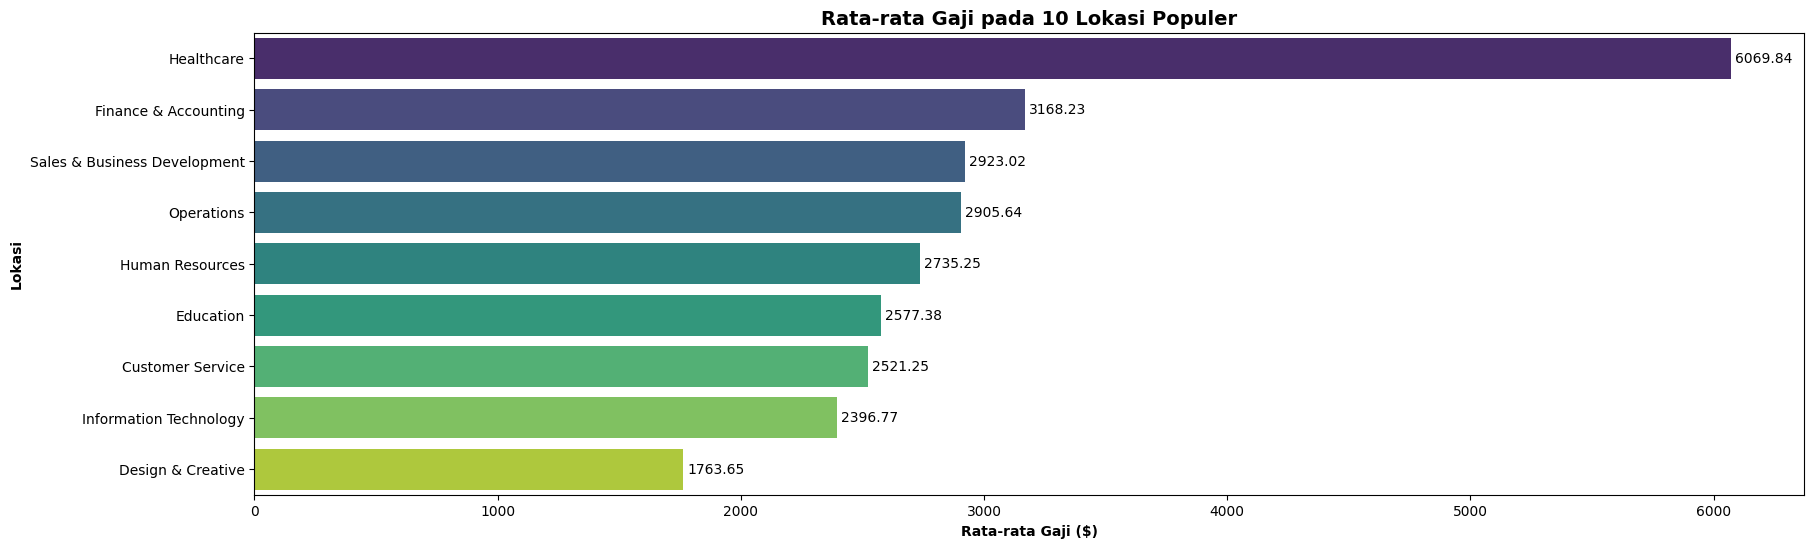

In [15]:
# Mengambil lokasi dengan lowongan terbanyak dahulu, lalu melihat gajinya
top_locations = df['category'].value_counts().head(10)
top_loc_df = df[df['category'].isin(top_locations.index)]

plt.figure(figsize=(20, 6))
gaji_per_lokasi = top_loc_df.groupby('category')['avg_sal_dollar'].mean().sort_values(ascending=False)
ax = sns.barplot(x=gaji_per_lokasi.values, y=gaji_per_lokasi.index, hue=gaji_per_lokasi.index, palette='viridis', legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Rata-rata Gaji pada 10 Lokasi Populer', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Gaji ($)', fontweight='bold')
plt.ylabel('Lokasi', fontweight='bold')
plt.show()

- **Komparasi Tertinggi:** Kategori pekerjaan dengan rata-rata nilai kompensasi tertinggi dipegang oleh Healthcare dengan nilai rata-rata mencapai $6,070.
- **Kesimpulan:** Sektor yang memiliki volume lowongan sedikit (pada Tab Permintaan Pasar) seringkali mengompensasikannya dengan nilai rata-rata gaji yang jauh lebih tinggi demi memperebutkan talenta spesifik (scarcity premium).

# **Export Data**

In [16]:
# Export data yang diperlukan
# Membuat kolom yang diperlukan
df = pd.DataFrame(df[['job_id','job_title','job_description', 'job_skill_set', 'category']])

df.to_csv('dataset_final.csv', index=False)
print("Data berhasil diekspor sebagai 'dataset_final.csv'")
df.head()

Data berhasil diekspor sebagai 'dataset_final.csv'


,job_id,job_title,job_description,job_skill_set,category
0,270925008041,sr. hr recruiter (non it),preferred candidate profile . .,"[communication, manpower, staffing, convincing...",Human Resources
1,270925007584,fire and safety officer,ensure active fire protection systemsuch as fi...,"[safety officer activities, fire protection, f...",Operations
2,270925007492,opening for performance marketing - chennai,mba marketing preferred tier ii or iii b- scho...,"[performance marketing, user acquisition, grow...",Sales & Business Development
3,270925007443,medical billing executive,job title-medical billing executive location-m...,"[fluent english, spoken english, good english ...",Healthcare
4,270925007430,senior group product manager - cns therapy,principal tasks responsibilities please write ...,"[product marketing, cns, product management, n...",Information Technology
